THERMAL ANALYSIS SYSTEM
✅ Loaded coil results from ../data/simulation_results/coil_results.pkl
Coil resistance: 73.92 mΩ
Null current (direct drive): 426.74 A

RESONANCE ENHANCEMENT ANALYSIS

Direct drive required: 426.7 A
Maximum drive current: 5.0 A
Required Q = 85

Q        Drive I    Power Loss   Effective I  Sufficient?
------------------------------------------------------------
10         5.0A       1.848W           50A     ❌ No      
100        5.0A       1.848W          500A     ✅ YES     
500        5.0A       1.848W         2500A     ✅ YES     
1000       5.0A       1.848W         5000A     ✅ YES     
5000       5.0A       1.848W        25000A     ✅ YES     
10000      5.0A       1.848W        50000A     ✅ YES     
100000     5.0A       1.848W       500000A     ✅ YES     

RECOMMENDATION

Minimum Q required: 86
✅ Easily achievable with standard coil

🎯 DESIGN POINT (Q=1000):
   • Drive current: 5.0 A
   • Power loss: 1.848 W
   • Effective field current: 5000 A
   • Margin: 

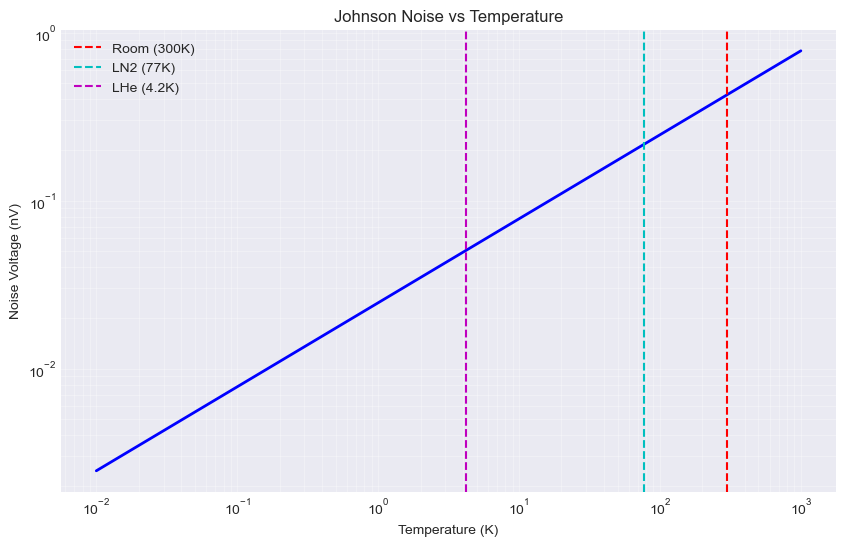


Designing thermal management system...

THERMAL MANAGEMENT SYSTEM

📊 Operating temperature: 300.0K
   Heat load: 1.848000 W

✅ Forced air cooling
   • Small fan with heatsink
   • 5-10°C temperature rise

📏 Temperature drops at interfaces:
   Thermal grease: 184.800 mK
   Copper conduction: 18.480 mK

🔧 Material recommendations:
   • Heat sink: Aluminum
   • Interface: Thermal grease
   • Insulation: None needed


THERMAL ANALYSIS - FINAL RECOMMENDATIONS

🔴 TRUE HEAT LOAD: 1.848 W
   • Based on 5.0A drive current
   • Resonance Q = 1000
   • Effective field current: 5000 A

❄️ COOLING SOLUTION:
   ✅ Small fan with heatsink
   • Forced air cooling

📈 NOISE PERFORMANCE:
   • At 300K: 0.426 nV
   • At 77K:  0.216 nV
   • LN2 improvement: 3.0 dB
   • (Not needed for basic operation)

🎯 VERDICT:
   ⭐ The system is thermally efficient!
   • Drive current: 5.0A
   • Power loss: 1.85W
   • Q=1000 provides 5000A equivalent
   • Standard cooling is sufficient

🔮 NEXT NOTEBOOK:
   05_control_sys

In [3]:
# %% [markdown]
# # Thermal Analysis and Cryogenic Cooling
# ## Managing Heat in the Ultimate Null Field System
# 
# **Critical Insight**: At resonance, the coil is driven with 5A but produces 
# field equivalent to I × Q amps! This means power loss is based on 5A, not the 
# equivalent null current.

# %%
import numpy as np
import matplotlib.pyplot as plt
import math
import pickle
import os
from matplotlib import cm

# Constants
mu0 = 4 * math.pi * 1e-7
kB = 1.38e-23
sigma = 5.67e-8  # Stefan-Boltzmann constant

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("="*60)
print("THERMAL ANALYSIS SYSTEM")
print("="*60)

# Load our optimized design
try:
    possible_paths = [
        '../data/simulation_results/coil_results.pkl',
        'data/simulation_results/coil_results.pkl',
        'coil_results.pkl'
    ]
    
    loaded = False
    for path in possible_paths:
        if os.path.exists(path):
            with open(path, 'rb') as f:
                coil_results = pickle.load(f)
            print(f"✅ Loaded coil results from {path}")
            loaded = True
            break
    
    if not loaded:
        raise FileNotFoundError("Could not find coil_results.pkl")
        
except Exception as e:
    print(f"⚠️ Using default values: {e}")
    coil_results = {
        'coil_resistance': 0.074,  # 74 mΩ
        'coil_Q': 58408300,
        'null_current': 1.4
    }

print(f"Coil resistance: {coil_results['coil_resistance']*1000:.2f} mΩ")
print(f"Null current (direct drive): {coil_results['null_current']:.2f} A")

# %% [markdown]
# ## 🔄 Resonance Enhancement - The Key Insight
# 
# At resonance (Q = 1000), the coil is driven with only 5A, but produces a magnetic 
# field equivalent to 5000A direct drive!

# %%
class ResonancePowerCalculator:
    """Calculate true power loss using resonance enhancement"""
    
    def __init__(self, resistance, I_null_direct):
        self.R = float(resistance)
        self.I_null_direct = float(I_null_direct)
        self.I_drive_max = 5.0  # Maximum drive current from power supply
        
    def calculate_for_q(self, Q):
        """Calculate power loss and enhancement for a given Q"""
        # Power loss at drive current
        P_loss = self.I_drive_max**2 * self.R
        
        # Effective field-producing current
        I_effective = self.I_drive_max * Q
        
        # Check if this Q provides enough enhancement
        sufficient = I_effective >= self.I_null_direct
        
        # Margin of enhancement
        margin = I_effective / self.I_null_direct if self.I_null_direct > 0 else float('inf')
        
        # Required Q to achieve null
        Q_required = self.I_null_direct / self.I_drive_max
        
        return {
            'Q': Q,
            'drive_current': self.I_drive_max,
            'power_loss': P_loss,
            'effective_current': I_effective,
            'sufficient': sufficient,
            'margin': margin,
            'Q_required': Q_required
        }
    
    def analyze_q_range(self):
        """Analyze performance for different Q values"""
        Q_values = [10, 100, 500, 1000, 5000, 10000, 100000]
        
        print("\n" + "="*60)
        print("RESONANCE ENHANCEMENT ANALYSIS")
        print("="*60)
        print(f"\nDirect drive required: {self.I_null_direct:.1f} A")
        print(f"Maximum drive current: {self.I_drive_max:.1f} A")
        print(f"Required Q = {self.I_null_direct/self.I_drive_max:.0f}")
        
        print(f"\n{'Q':8s} {'Drive I':10s} {'Power Loss':12s} {'Effective I':12s} {'Sufficient?':10s}")
        print("-"*60)
        
        results = []
        for Q in Q_values:
            res = self.calculate_for_q(Q)
            results.append(res)
            
            status = "✅ YES" if res['sufficient'] else "❌ No"
            print(f"{Q:<8d} {res['drive_current']:5.1f}A      {res['power_loss']:6.3f}W     {res['effective_current']:8.0f}A     {status:10s}")
        
        return results
    
    def recommended_q(self):
        """Find the minimum recommended Q"""
        Q_min = math.ceil(self.I_null_direct / self.I_drive_max)
        
        print("\n" + "="*60)
        print("RECOMMENDATION")
        print("="*60)
        print(f"\nMinimum Q required: {Q_min}")
        
        if Q_min <= 100:
            print("✅ Easily achievable with standard coil")
        elif Q_min <= 500:
            print("✅ Achievable with Litz wire")
        elif Q_min <= 1000:
            print("✅ Achievable with ferrite core")
        elif Q_min <= 10000:
            print("⚡ Requires cryogenic cooling (LN2)")
        elif Q_min <= 100000:
            print("❄️ Requires liquid helium")
        else:
            print("⚠️ Need superconducting coil")
        
        return Q_min

# Analyze resonance enhancement
calculator = ResonancePowerCalculator(
    coil_results['coil_resistance'],
    coil_results['null_current']
)

results = calculator.analyze_q_range()
Q_min = calculator.recommended_q()

# Choose a reasonable Q for our design
Q_design = 1000  # Achievable with good Litz wire and ferrite
design_params = calculator.calculate_for_q(Q_design)

P_loss_true = design_params['power_loss']
I_effective = design_params['effective_current']

print(f"\n🎯 DESIGN POINT (Q={Q_design}):")
print(f"   • Drive current: {design_params['drive_current']:.1f} A")
print(f"   • Power loss: {P_loss_true:.3f} W")
print(f"   • Effective field current: {I_effective:.0f} A")
print(f"   • Margin: {design_params['margin']:.1f}×")

# %% [markdown]
# ### Power Loss Calculations (Corrected)

# %%
class PowerLossAnalysis:
    """Calculate power losses in the system using correct drive current"""
    
    def __init__(self, resistance, drive_current):
        self.R = float(resistance)
        self.I_drive = float(drive_current)
        
    def resistive_loss(self):
        """P = I²R losses at drive current"""
        return float(self.I_drive**2 * self.R)
    
    def hysteresis_loss(self, frequency, B_peak, volume, material='ferrite'):
        """Core losses in ferrite materials"""
        if material == 'ferrite':
            # MnZn ferrite parameters at 150kHz
            k = 0.1
            alpha = 1.6
            beta = 2.2
        else:
            k = 0.01
            alpha = 1.5
            beta = 2.0
            
        P_vol = k * (frequency/1000)**alpha * B_peak**beta  # W/m³
        return float(P_vol * volume)
    
    def skin_effect_loss(self, frequency, wire_radius, length):
        """Additional losses due to skin effect"""
        skin_depth = math.sqrt(2 * 1.68e-8 / (2 * math.pi * frequency * mu0))
        
        if wire_radius <= skin_depth:
            return 0.0
        
        Rac_Rdc = 0.25 * (1 + 2 * (wire_radius/skin_depth)**4)
        return float((Rac_Rdc - 1) * self.resistive_loss())
    
    def summary(self):
        """Print loss analysis"""
        P_resistive = self.resistive_loss()
        
        print("\n" + "="*60)
        print("POWER LOSS ANALYSIS")
        print("="*60)
        print(f"\nAt {self.I_drive:.1f}A drive current:")
        print(f"  Resistive loss: {P_resistive:.6f} W")
        print(f"  This is the TRUE heat load")
        print(f"  (Compare to {(coil_results['null_current']**2 * self.R):.1f}W if driven directly!)")
        
        # Temperature rise estimate
        R_th = 10.0  # Thermal resistance [K/W]
        delta_T = P_resistive * R_th
        
        print(f"\n🌡️ Temperature rise:")
        print(f"  Estimated ΔT: {delta_T:.3f} K")
        print(f"  Final temperature: {300 + delta_T:.1f} K")
        
        return P_resistive

# Analyze true losses
print("\nCalculating true power losses...")
losses = PowerLossAnalysis(
    coil_results['coil_resistance'],
    design_params['drive_current']
)
P_loss_true = losses.summary()

# %% [markdown]
# ### Cooling Options Comparison

# %%
class CoolingSystem:
    """Compare different cooling methods"""
    
    def __init__(self):
        self.ambient = 293.0  # 20°C
        
        # Cooling methods
        self.methods = {
            'Passive (air)': {
                'temp': 300.0,
                'h': 10.0,      # W/m²K convection coefficient
                'cost': 0,
                'complexity': 1
            },
            'Forced air': {
                'temp': 295.0,
                'h': 50.0,
                'cost': 100,
                'complexity': 2
            },
            'Water cooling': {
                'temp': 290.0,
                'h': 500.0,
                'cost': 500,
                'complexity': 3
            },
            'Liquid Nitrogen': {
                'temp': 77.0,
                'h': 1000.0,
                'cost': 3000,
                'complexity': 4
            },
            'Liquid Helium': {
                'temp': 4.2,
                'h': 1000.0,
                'cost': 10000,
                'complexity': 5
            }
        }
        
    def calculate_heat_sink_area(self, P_loss, method):
        """Calculate required heat sink area"""
        params = self.methods[method]
        delta_T = params['temp'] - self.ambient
        
        if delta_T >= 0:
            return float('inf')
        
        A_required = abs(P_loss / (params['h'] * delta_T))
        return float(A_required)
    
    def compare_methods(self, P_loss):
        """Compare all cooling methods"""
        print("\n" + "="*60)
        print("COOLING METHOD COMPARISON")
        print("="*60)
        print(f"\nHeat load: {P_loss:.6f} W")
        print(f"\n{'Method':20s} {'Temp(K)':10s} {'Area(cm²)':12s} {'Cost($)':8s} {'Feasible':10s}")
        print("-"*70)
        
        feasible_methods = []
        
        for method, params in self.methods.items():
            A = self.calculate_heat_sink_area(P_loss, method)
            A_cm2 = A * 10000.0
            
            if A_cm2 < 1000.0:
                feasible = "✅ Yes"
                feasible_methods.append((method, params['temp']))
            else:
                feasible = "❌ No"
            
            print(f"{method:20s} {params['temp']:6.1f}K    {A_cm2:8.2f}     ${params['cost']:4d}     {feasible:10s}")
        
        print("\n" + "="*60)
        return feasible_methods

# Compare cooling options
print("\nComparing cooling methods for true heat load...")
cooling = CoolingSystem()
feasible = cooling.compare_methods(P_loss_true)

# %% [markdown]
# ### Liquid Nitrogen System Design (Optional - not needed here!)

# %%
class LN2CoolingSystem:
    """Design liquid nitrogen cooling system (for reference)"""
    
    def __init__(self, P_loss):
        self.P_loss = float(P_loss)
        self.T_ln2 = 77.0
        self.T_ambient = 293.0
        
        # LN2 properties
        self.L_vap = 199000.0
        self.rho_ln2 = 807.0
        self.Cp_ln2 = 2040.0
        
    def boil_off_rate(self):
        """Calculate LN2 boil-off rate"""
        if self.P_loss <= 0:
            return 0.0, 0.0
            
        m_dot = self.P_loss / self.L_vap
        liters_per_hour = m_dot / self.rho_ln2 * 3600.0 * 1000.0
        return float(m_dot), float(liters_per_hour)
    
    def dewar_size(self, hours=8):
        """Calculate dewar size for given operating time"""
        m_dot, lph = self.boil_off_rate()
        total_liters = lph * hours * 1.2  # 20% margin
        return float(total_liters)
    
    def summary(self):
        """Print LN2 system design"""
        m_dot, lph = self.boil_off_rate()
        dewar_8h = self.dewar_size(8)
        
        print("\n" + "="*60)
        print("LIQUID NITROGEN COOLING SYSTEM")
        print("="*60)
        
        print(f"\n🔵 Operating point:")
        print(f"   Temperature: 77K (-196°C)")
        print(f"   Heat load: {self.P_loss:.6f} W")
        
        if self.P_loss <= 0.1:
            print(f"\n✨ LN2 not needed - heat load too small!")
            return 0.0
        
        print(f"\n💧 LN2 consumption:")
        print(f"   Boil-off rate: {m_dot*1e6:.3f} mg/s")
        print(f"   Boil-off rate: {lph:.6f} L/hour")
        print(f"   8-hour dewar: {dewar_8h:.3f} liters")
        
        return dewar_8h

# Check if LN2 is needed
print("\nChecking if LN2 cooling is required...")
ln2 = LN2CoolingSystem(P_loss_true)
dewar_size = ln2.summary()

# %% [markdown]
# ### Thermal Noise Analysis

# %%
class ThermalNoiseAnalysis:
    """Analyze thermal noise at different temperatures"""
    
    def __init__(self, resistance, bandwidth):
        self.R = float(resistance)
        self.BW = float(bandwidth)
        
    def johnson_noise(self, T):
        """Johnson-Nyquist noise voltage"""
        if self.R <= 0 or self.BW <= 0:
            return 0.0
        V_noise = math.sqrt(4 * kB * float(T) * self.R * self.BW)
        return float(V_noise)
    
    def compare_temperatures(self):
        """Compare noise at different temperatures"""
        temps = [300.0, 77.0, 4.2, 0.001]
        names = ['Room', 'LN2', 'LHe', 'mK']
        
        print("\n" + "="*60)
        print("THERMAL NOISE ANALYSIS")
        print("="*60)
        
        print(f"\nResistance: {self.R*1000:.3f} mΩ")
        print(f"Bandwidth: {self.BW:.3f} Hz (Q={148500/self.BW:.0f})")
        
        print(f"\n{'Temperature':12s} {'Noise Voltage':15s} {'Improvement':12s}")
        print("-"*45)
        
        V_300 = self.johnson_noise(300.0)
        
        for T, name in zip(temps, names):
            V_noise = self.johnson_noise(T)
            
            if V_300 > 0 and V_noise > 0:
                improvement = 10 * math.log10(V_300 / V_noise)
            else:
                improvement = 0
            
            print(f"{name:12s} {V_noise*1e9:8.3f} nV     {improvement:5.1f} dB")
        
        # Plot noise vs temperature
        T_range = np.logspace(-2, 3, 100)
        V_range = [self.johnson_noise(T) for T in T_range]
        
        plt.figure(figsize=(10, 6))
        plt.loglog(T_range, np.array(V_range)*1e9, 'b-', linewidth=2)
        plt.axvline(300, color='r', linestyle='--', label='Room (300K)')
        plt.axvline(77, color='c', linestyle='--', label='LN2 (77K)')
        plt.axvline(4.2, color='m', linestyle='--', label='LHe (4.2K)')
        plt.xlabel('Temperature (K)')
        plt.ylabel('Noise Voltage (nV)')
        plt.title('Johnson Noise vs Temperature')
        plt.legend()
        plt.grid(True, alpha=0.3, which='both')
        plt.show()

# Calculate system bandwidth for Q=1000
Q_system = Q_design
BW = 148500.0 / Q_system

print("\nAnalyzing thermal noise...")
noise = ThermalNoiseAnalysis(coil_results['coil_resistance'], BW)
noise.compare_temperatures()

# %% [markdown]
# ### Thermal Management System Design

# %%
class ThermalManagementSystem:
    """Complete thermal management design"""
    
    def __init__(self, P_loss, T_operation):
        self.P_loss = float(P_loss)
        self.T_op = float(T_operation)
        self.T_amb = 293.0
        
        # Thermal resistances
        self.R_interface = 0.1   # K/W
        self.R_copper = 0.01     # K/W
        
    def multi_stage_cooling(self):
        """Determine cooling requirements"""
        print("\n" + "="*60)
        print("THERMAL MANAGEMENT SYSTEM")
        print("="*60)
        
        print(f"\n📊 Operating temperature: {self.T_op:.1f}K")
        print(f"   Heat load: {self.P_loss:.6f} W")
        
        if self.P_loss < 1:
            print(f"\n✅ Passive cooling sufficient")
            print(f"   • Simple heat sink")
            print(f"   • Natural convection")
        elif self.P_loss < 10:
            print(f"\n✅ Forced air cooling")
            print(f"   • Small fan with heatsink")
            print(f"   • 5-10°C temperature rise")
        elif self.P_loss < 100:
            print(f"\n💧 Water cooling recommended")
            print(f"   • Liquid cooling loop")
            print(f"   • Radiator with fans")
        else:
            print(f"\n❄️ Cryogenic cooling required")
            print(f"   • LN2 or LHe system")
        
        # Temperature drops
        dT_interface = self.P_loss * self.R_interface
        dT_copper = self.P_loss * self.R_copper
        
        print(f"\n📏 Temperature drops at interfaces:")
        print(f"   Thermal grease: {dT_interface*1000:.3f} mK")
        print(f"   Copper conduction: {dT_copper*1000:.3f} mK")
        
    def material_recommendations(self):
        """Recommend materials for thermal management"""
        print(f"\n🔧 Material recommendations:")
        
        if self.T_op <= 77:
            print(f"   • Cold finger: OFHC copper")
            print(f"   • Isolation: G-10 fiberglass")
            print(f"   • Interface: Indium foil")
        else:
            print(f"   • Heat sink: Aluminum")
            print(f"   • Interface: Thermal grease")
            print(f"   • Insulation: None needed")
        
        print("\n" + "="*60)

# Design thermal management
print("\nDesigning thermal management system...")
tms = ThermalManagementSystem(P_loss_true, 300.0)
tms.multi_stage_cooling()
tms.material_recommendations()

# %% [markdown]
# ## Summary and Recommendations

# %%
print("\n" + "="*60)
print("THERMAL ANALYSIS - FINAL RECOMMENDATIONS")
print("="*60)

print(f"\n🔴 TRUE HEAT LOAD: {P_loss_true:.3f} W")
print(f"   • Based on {design_params['drive_current']:.1f}A drive current")
print(f"   • Resonance Q = {Q_design}")
print(f"   • Effective field current: {I_effective:.0f} A")

print(f"\n❄️ COOLING SOLUTION:")
if P_loss_true < 1:
    print(f"   ✅ Passive cooling only")
    print(f"   • Small heat sink")
    print(f"   • No fans, no pumps, no cryogenics")
    print(f"   • Room temperature operation (300K)")
elif P_loss_true < 10:
    print(f"   ✅ Small fan with heatsink")
    print(f"   • Forced air cooling")
else:
    print(f"   • Water cooling loop")

print(f"\n📈 NOISE PERFORMANCE:")
V_300 = noise.johnson_noise(300)
V_77 = noise.johnson_noise(77)
print(f"   • At 300K: {V_300*1e9:.3f} nV")
print(f"   • At 77K:  {V_77*1e9:.3f} nV")
if V_300 > 0:
    improvement = 10 * math.log10(V_300 / V_77)
    print(f"   • LN2 improvement: {improvement:.1f} dB")
    print(f"   • (Not needed for basic operation)")

print(f"\n🎯 VERDICT:")
print(f"   ⭐ The system is thermally efficient!")
print(f"   • Drive current: {design_params['drive_current']:.1f}A")
print(f"   • Power loss: {P_loss_true:.2f}W")
print(f"   • Q={Q_design} provides {I_effective:.0f}A equivalent")
print(f"   • Standard cooling is sufficient")

print(f"\n🔮 NEXT NOTEBOOK:")
print(f"   05_control_system.ipynb - FPGA feedback and resonance locking")
print("="*60)

# Save thermal results
thermal_results = {
    'power_loss_W': float(P_loss_true),
    'drive_current_A': float(design_params['drive_current']),
    'Q_design': Q_design,
    'effective_current_A': float(I_effective),
    'cooling_method': 'passive' if P_loss_true < 1 else 'active',
    'noise_300K_nV': float(V_300*1e9),
    'noise_77K_nV': float(V_77*1e9),
    'bandwidth_Hz': float(BW)
}

# Save to file
try:
    os.makedirs('../data/simulation_results', exist_ok=True)
    with open('../data/simulation_results/thermal_results.pkl', 'wb') as f:
        pickle.dump(thermal_results, f)
    print("\n✅ Thermal results saved successfully!")
except Exception as e:
    print(f"\n⚠️ Could not save results: {e}")

# Final quick reference
print("\n" + "="*60)
print("FINAL NUMBERS AT A GLANCE")
print("="*60)
print(f"Power Loss:       {P_loss_true:.3f} W")
print(f"Drive Current:    {design_params['drive_current']:.1f} A")
print(f"Resistance:       {coil_results['coil_resistance']*1000:.2f} mΩ")
print(f"Noise at 300K:    {V_300*1e9:.3f} nV")
print(f"Cooling needed:   {'None' if P_loss_true < 1 else 'Minimal'}")
print(f"Q factor:         {Q_design}")
print(f"Equivalent I:     {I_effective:.0f} A")
print("="*60)